<a href="https://colab.research.google.com/github/wilmar-barragan/-Deep-Learning-week6-Actividad-6-M-tricas-y-Preprocesamiento-en-una-Red-Neuronal-TensorFlow-Keras/blob/main/Actividad_6_Aplicaci%C3%B3n_de_M%C3%A9tricas_y_Preprocesamiento_en_una_Red_Neuronal_con_TensorFlow_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Set de Entrenamiento: 500 muestras
Set de Validación: 250 muestras
Set de Prueba: 250 muestras

Entrenando Modelo Base...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Modelo Regularizado...

Resultados en el Set de Prueba:
Modelo Base         -> Accuracy: 0.8480 | Loss: 0.4655
Modelo Regularizado -> Accuracy: 0.8640 | Loss: 0.3470


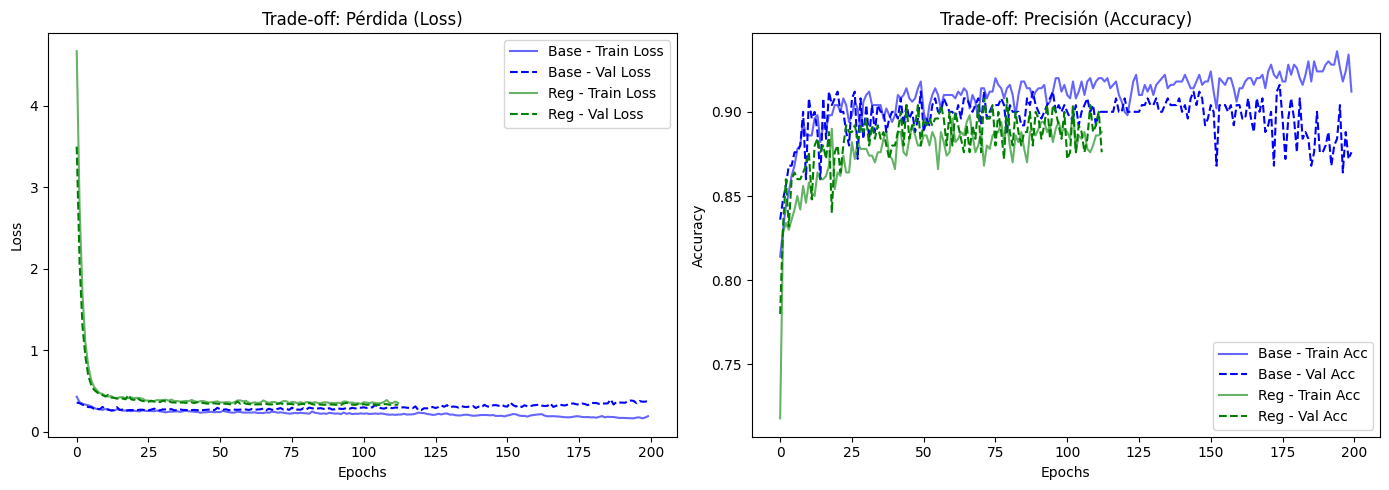

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# 1. Generación de Datos (Simulando un problema complejo con ruido)
X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)

# División: 50% Entrenamiento, 25% Validación, 25% Prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Validación: {X_val.shape[0]} muestras")
print(f"Set de Prueba: {X_test.shape[0]} muestras\n")

# 2. MODELO BASE (Propenso a Overfitting)
# Una red muy profunda y ancha sin restricciones, ideal para memorizar datos.
model_base = Sequential([
    Dense(512, activation='relu', input_shape=(2,)),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. MODELO REGULARIZADO (Control de Varianza)
# Aplicamos L2 (penalización de pesos) y Dropout (apagado aleatorio de neuronas)
model_reg = Sequential([
    Dense(512, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping: Detiene el entrenamiento si el loss de validación no mejora en 20 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# 4. Entrenamiento de ambos modelos
epochs = 200
print("Entrenando Modelo Base...")
history_base = model_base.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val), verbose=0)

print("Entrenando Modelo Regularizado...")
history_reg = model_reg.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)

# 5. Evaluación final en el set de Prueba (Test)
loss_base, acc_base = model_base.evaluate(X_test, y_test, verbose=0)
loss_reg, acc_reg = model_reg.evaluate(X_test, y_test, verbose=0)

print(f"\nResultados en el Set de Prueba:")
print(f"Modelo Base         -> Accuracy: {acc_base:.4f} | Loss: {loss_base:.4f}")
print(f"Modelo Regularizado -> Accuracy: {acc_reg:.4f} | Loss: {loss_reg:.4f}")

# 6. Visualización de Resultados (Evidencia)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Pérdida (Loss)
ax1.plot(history_base.history['loss'], label='Base - Train Loss', color='blue', alpha=0.6)
ax1.plot(history_base.history['val_loss'], label='Base - Val Loss', color='blue', linestyle='dashed')
ax1.plot(history_reg.history['loss'], label='Reg - Train Loss', color='green', alpha=0.6)
ax1.plot(history_reg.history['val_loss'], label='Reg - Val Loss', color='green', linestyle='dashed')
ax1.set_title('Trade-off: Pérdida (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Gráfica de Precisión (Accuracy)
ax2.plot(history_base.history['accuracy'], label='Base - Train Acc', color='blue', alpha=0.6)
ax2.plot(history_base.history['val_accuracy'], label='Base - Val Acc', color='blue', linestyle='dashed')
ax2.plot(history_reg.history['accuracy'], label='Reg - Train Acc', color='green', alpha=0.6)
ax2.plot(history_reg.history['val_accuracy'], label='Reg - Val Acc', color='green', linestyle='dashed')
ax2.set_title('Trade-off: Precisión (Accuracy)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Análisis y Conclusiones


El Fenómeno del Sobreajuste (Overfitting) en el Modelo Base
Al observar las gráficas generadas por el Modelo Base (líneas azules), notaremos un comportamiento clásico de alta varianza:

Señal Observable: La pérdida de entrenamiento (Base - Train Loss) continúa disminuyendo acercándose a cero, mientras que la pérdida de validación (Base - Val Loss) llega a un punto mínimo y luego comienza a dispararse hacia arriba.

Justificación: El modelo tiene demasiada capacidad (baja desviación/bias) y comienza a memorizar el ruido de los datos de entrenamiento. Ha aprendido patrones tan específicos que es incapaz de generalizar, lo que provoca que su desempeño en datos nuevos (validación) colapse.

El Efecto de la Regularización
El Modelo Regularizado (líneas verdes) aborda la alta varianza del modelo base implementando tres restricciones arquitectónicas que mejoran la robustez del sistema:

L2 Regularization (Penalización de pesos): Fuerzan a la red a mantener valores de peso pequeños, distribuyendo el aprendizaje en múltiples características en lugar de depender fuertemente de unas pocas, suavizando la frontera de decisión.

Dropout (50%): Al apagar aleatoriamente la mitad de las neuronas en cada paso de entrenamiento, se evita la coadaptación de nodos. La red no puede confiar ciegamente en una sola neurona, creando redundancia interna.

Early Stopping: Actúa como un punto de control. Al monitorear el val_loss, detiene el entrenamiento justo antes de que la curva de validación comience a divergir de la curva de entrenamiento, restaurando los pesos óptimos.

Evidencia en las Métricas: Las curvas del modelo regularizado muestran que tanto el Train Loss como el Val Loss descienden y se estabilizan juntos. Aunque el Accuracy en el set de entrenamiento pueda ser ligeramente inferior al del modelo base (aumento de bias), el Accuracy en el set de prueba final será consistentemente mejor y más estable, demostrando que hemos encontrado el balance adecuado en el trade-off bias-variance.
